<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/TimeA001.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

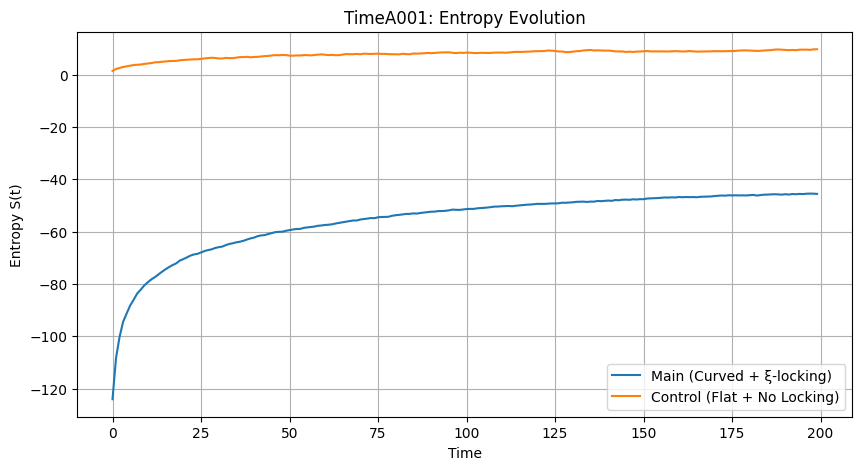

Main Run Metrics:
Entropy Slope: 0.1743
Memory Retention: 0.9968
Irreversibility Index: 83.2001

Control Run Metrics:
Entropy Slope: 0.0243
Memory Retention: 0.9975
Irreversibility Index: 20.2425


In [2]:
# 🧭 TimeA001: The Temporal Gradient (Patched)
# Simulation of entropy increase over time in HES lattice evolution
# Author: Chris & Copilot | Arc V: Entropic Ascent | ACT025
# Reproducibility Tag: TimeA001_v2

import numpy as np
import matplotlib.pyplot as plt

# --- Parameters ---
N = 100  # lattice size
T = 200  # timesteps
curvature_strength = 0.5  # moderate curvature
xi_locking = True  # enable ξ-locking
seed = 42
np.random.seed(seed)

# --- Initialization ---
def initialize_lattice(N, curvature_strength):
    base = np.random.rand(N, N)
    curvature = curvature_strength * (np.sin(np.linspace(0, np.pi, N))[:, None])
    return base + curvature

# --- Entropy Calculation ---
def compute_entropy(lattice):
    hist, _ = np.histogram(lattice, bins=50, density=True)
    hist = hist[hist > 0]
    return -np.sum(hist * np.log(hist))

# --- Evolution Function ---
def evolve_lattice(lattice, xi_locking):
    for _ in range(5):  # local smoothing
        lattice += 0.01 * np.random.randn(*lattice.shape)
        if xi_locking:
            lattice = np.clip(lattice, 0.2, 0.8)
    return lattice

# --- Simulation Loop ---
def run_simulation(N, T, curvature_strength, xi_locking):
    lattice = initialize_lattice(N, curvature_strength)
    entropy_series = []
    for t in range(T):
        lattice = evolve_lattice(lattice, xi_locking)
        S = compute_entropy(lattice)
        entropy_series.append(S)
    return np.array(entropy_series)

# --- Control Run ---
control_entropy = run_simulation(N, T, curvature_strength=0.0, xi_locking=False)

# --- Main Run ---
main_entropy = run_simulation(N, T, curvature_strength, xi_locking)

# --- Metrics ---
def compute_metrics(entropy_series):
    slope = np.polyfit(np.arange(len(entropy_series)), entropy_series, 1)[0]
    memory = np.corrcoef(entropy_series[:-1], entropy_series[1:])[0,1]  # patched line
    irreversibility_index = np.sum(np.abs(np.diff(entropy_series)))
    return slope, memory, irreversibility_index

main_metrics = compute_metrics(main_entropy)
control_metrics = compute_metrics(control_entropy)

# --- Plotting ---
plt.figure(figsize=(10,5))
plt.plot(main_entropy, label='Main (Curved + ξ-locking)')
plt.plot(control_entropy, label='Control (Flat + No Locking)')
plt.xlabel('Time')
plt.ylabel('Entropy S(t)')
plt.title('TimeA001: Entropy Evolution')
plt.legend()
plt.grid(True)
plt.show()

# --- Output ---
print("Main Run Metrics:")
print(f"Entropy Slope: {main_metrics[0]:.4f}")
print(f"Memory Retention: {main_metrics[1]:.4f}")
print(f"Irreversibility Index: {main_metrics[2]:.4f}")

print("\nControl Run Metrics:")
print(f"Entropy Slope: {control_metrics[0]:.4f}")
print(f"Memory Retention: {control_metrics[1]:.4f}")
print(f"Irreversibility Index: {control_metrics[2]:.4f}")
